( 111 )  2θ = 43.51 degrees
( 002 )  2θ = 50.67 degrees
( 022 )  2θ = 74.49 degrees
( 113 )  2θ = 90.42 degrees
( 222 )  2θ = 95.67 degrees
( 004 )  2θ = 117.72 degrees
( 133 )  2θ = 137.71 degrees
( 024 )  2θ = 146.24 degrees


Text(0.5, 1.0, 'Simulated FCC XRD Pattern')

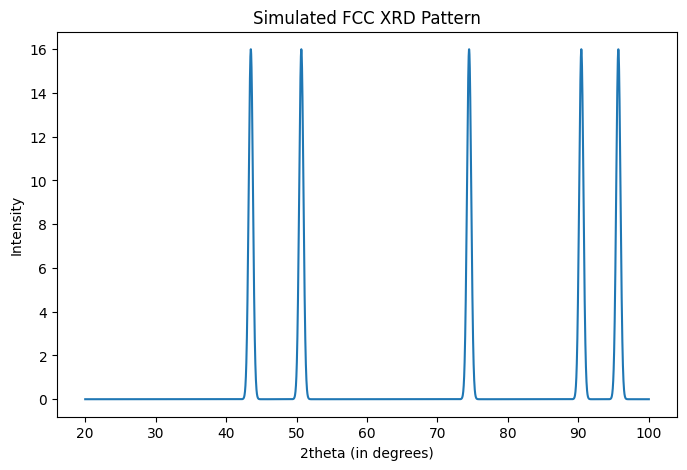

In [1]:
import numpy as np
import matplotlib.pyplot as plt
lat_param = 3.6
wavelength = 1.5406

peaks=[]

for h in range(5):
  for k in range(5):
    for l in range(5):
      if(h==0 and k==0 and l==0):
        continue

      if(h%2==k%2==l%2):
          peaks.append((h,k,l))

ans=[]
for (h,k,l) in peaks:
  sq=h**2+k**2+l**2
  d=lat_param/np.sqrt(sq)
  value = wavelength/(2*d)
  if(value<=1):
    theta=np.arcsin(value)
    two_theta=2*theta

    two_theta_degree=np.degrees(two_theta)
    ans.append((h,k,l,two_theta_degree))

unique_peaks = {}

for (h,k,l ) in peaks:

    h2k2l2 = h**2 + k**2 + l**2
    d = lat_param/ np.sqrt(h2k2l2)

    value = wavelength / (2*d)

    if value <= 1:
        theta = np.arcsin(value)
        two_theta = 2 * theta
        two_theta_deg = np.degrees(two_theta)

        if h2k2l2 not in unique_peaks:
            unique_peaks[h2k2l2] = (h, k, l, two_theta_deg)

final_peaks = list(unique_peaks.values())

# Sort by 2theta
final_peaks.sort(key=lambda x: x[3])

for peak in final_peaks:
    print(f"( {peak[0]}{peak[1]}{peak[2]} )  2θ = {peak[3]:.2f} degrees")


two_theta_range = np.linspace(20,100,5000)

intensity_sf = np.zeros_like(two_theta_range)

sigma = 0.3

atoms = [
    (0,0,0),
    (0,0.5,0.5),
    (0.5,0,0.5),
    (0.5,0.5,0)
]

for peak in final_peaks:

    h, k, l, peak_position = peak

    F = 0

    for (x,y,z)in atoms:
        phase = 2*np.pi*(h*x + k*y + l*z)
        F += np.exp(1j*phase)

    I0 = np.abs(F)**2

    gaussian = I0 * np.exp(-(two_theta_range - peak_position)**2 / (2*sigma**2))

    intensity_sf += gaussian

plt.figure(figsize=(8,5))
plt.plot(two_theta_range,intensity_sf)
plt.xlabel("2theta (in degrees)")
plt.ylabel("Intensity")
plt.title("Simulated FCC XRD Pattern")


